<h1 style="color: #FECB05; text-align: center;">Visión por computadora</h1>


<h2 style="color: #007ACC;">Autores</h2>


- [Juan Felipe Contreras Alcívar](https://www.linkedin.com/in/juanf-contreras/)


---


<h2 style="color: #007ACC;">Tabla de contenido</h2>


- [<span style="color: #005C99;">Introducción</span>](#introduction)
- [<span style="color: #005C99;">Clasificación de imágenes</span>](#clasificacion)
- [<span style="color: #005C99;">Ejemplo: CIFAR-10</span>](#cifar)
- [<span style="color: #005C99;">Detección de objetos</span>](#deteccion)
- [<span style="color: #005C99;">Ejemplo: un objeto sintético</span>](#ejemplo-deteccion)
- [<span style="color: #005C99;">YOLO (idea)</span>](#yolo)
- [<span style="color: #005C99;">Segmentación semántica</span>](#segmentacion)
- [<span style="color: #005C99;">U-Net y ejemplo sintético</span>](#unet)
- [<span style="color: #005C99;">Problemas comunes</span>](#problemas)
- [<span style="color: #005C99;">Referencias</span>](#reference)


---


<h2 style="color: #007ACC;">Instalación de librerías</h2>

Ejecuta esta celda si trabajas en Google Colab o en un entorno nuevo.


In [1]:
# Instalación de librerías necesarias para esta sesión
# (útil en Google Colab o en un entorno nuevo)
%pip install -q numpy pandas matplotlib scikit-learn tensorflow


/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import (
    Concatenate,
    Conv2D,
    Conv2DTranspose,
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling2D,
    Input,
    MaxPooling2D,
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)


I0000 00:00:1786750404.393520   79694 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786750404.393828   79694 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786750404.416140   79694 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0


I0000 00:00:1786750405.038402   79694 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786750405.038558   79694 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
def plot_history(history, title="Curvas de entrenamiento"):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)
    acc_key = next((k for k in ("accuracy", "cls_accuracy") if k in hist), None)
    n = 2 if acc_key else 1
    plt.figure(figsize=(6 * n, 4))

    plt.subplot(1, n, 1)
    plt.plot(epochs, hist["loss"], label="train loss")
    if "val_loss" in hist:
        plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title(title + " — loss")
    plt.legend()
    plt.grid(True)

    if acc_key:
        plt.subplot(1, n, 2)
        plt.plot(epochs, hist[acc_key], label="train acc")
        val_key = "val_" + acc_key
        if val_key in hist:
            plt.plot(epochs, hist[val_key], label="val acc")
        plt.xlabel("Época")
        plt.ylabel("Accuracy")
        plt.title(title + " — accuracy")
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, classes, title="Matriz de confusión"):
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(classes))
    plt.xticks(ticks, classes, rotation=45, ha="right")
    plt.yticks(ticks, classes)
    thresh = cm.max() / 2.0 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, int(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=8,
            )
    plt.ylabel("Etiqueta verdadera")
    plt.xlabel("Etiqueta predicha")
    plt.tight_layout()
    plt.show()


def es_callbacks(patience=3):
    return [
        EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
    ]


<a id="introduction"></a>
<h2 style="color: #007ACC;">Introducción</h2>


La **visión por computadora** extrae información de imágenes (y video). En este cuaderno no repetimos el detalle de filtros y pooling de `05_Convoluciones.ipynb` ni el entrenamiento CNN de `06_CNN.ipynb`: aquí cerramos el mapa de **tres tareas** que aparecen en casi cualquier sistema visual.

| Tarea | Pregunta | Salida |
|---|---|---|
| **Clasificación** | ¿Qué hay en la imagen? | Una etiqueta para *toda* la imagen |
| **Detección** | ¿Qué hay y *dónde*? | Clase + cuadro delimitador por objeto |
| **Segmentación semántica** | ¿A qué clase pertenece *cada píxel*? | Máscara $H \times W$ |

<img src="../img/cv_tasks.svg" alt="Clasificación, detección y segmentación" width="920">

Las tres se apoyan en un **backbone** convolucional. Cambia la **cabeza**: un vector (clasificación), cajas + clases (detección), un mapa denso (segmentación).


<a id="clasificacion"></a>
<h2 style="color: #007ACC;">Clasificación de imágenes</h2>


Dada $x \in \mathbb{R}^{H \times W \times D}$, el modelo produce un vector de $C$ clases:

$$\hat{y} = \mathrm{softmax}(f(x;\theta)) \in \mathbb{R}^{C}$$

y se entrena con **entropía cruzada**. En Keras, con etiquetas enteras usamos `sparse_categorical_crossentropy` (no hace falta `to_categorical`).

La CNN apila convoluciones y pooling para pasar de píxeles a un descriptor, y una cabeza densa decide la clase. Eso ya se practicó en el cuaderno de CNN; aquí lo usamos como **primera estación** del pipeline de visión, con **CIFAR-10** (color, $32\times 32$, 10 clases), distinto de MNIST/Fashion y del gato-vs-perro de transfer learning.


<a id="cifar"></a>
<h2 style="color: #007ACC;">Ejemplo: CIFAR-10</h2>


A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 75s 0us/step
Train: (50000, 32, 32, 3) (50000,) | Test: (10000, 32, 32, 3)


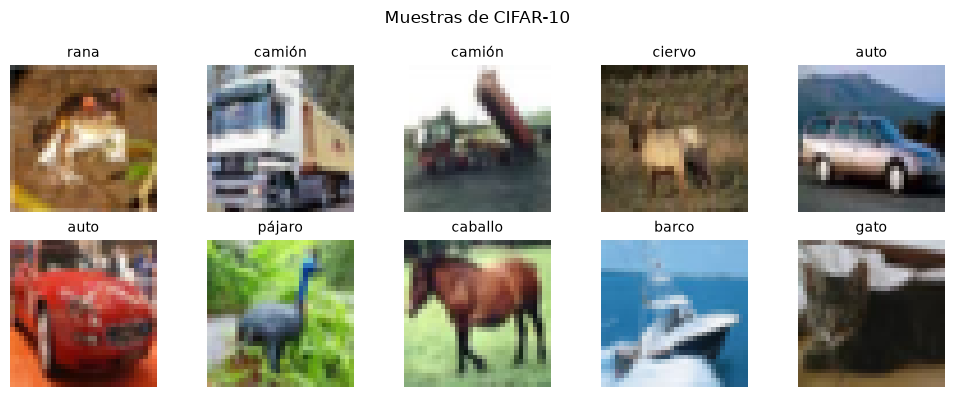

In [4]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train = y_train.ravel()
y_test = y_test.ravel()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

CIFAR_NAMES = [
    "avión", "auto", "pájaro", "gato", "ciervo",
    "perro", "rana", "caballo", "barco", "camión",
]
print("Train:", x_train.shape, y_train.shape, "| Test:", x_test.shape)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(CIFAR_NAMES[y_train[i]], fontsize=10)
    plt.axis("off")
plt.suptitle("Muestras de CIFAR-10")
plt.tight_layout()
plt.show()


/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1786750482.078582   79694 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1786750482.078844   79832 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1786750482.099762   79694 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are ins

Model: "cifar_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,130 (238.79 KB)

 Trainable params: 61,130 (238.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2496 - loss: 1.9559 - val_accuracy: 0.3576 - val_loss: 1.7013 - learning_rate: 0.0010
Epoch 2/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3345 - loss: 1.7261 - val_accuracy: 0.4042 - val_loss: 1.5867 - learning_rate: 0.0010
Epoch 3/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3929 - loss: 1.6118 - val_accuracy: 0.4418 - val_loss: 1.4909 - learning_rate: 0.0010
Epoch 4/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4345 - loss: 1.5243 - val_accuracy: 0.4716 - val_loss: 1.4245 - learning_rate: 0.0010
Epoch 5/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4698 - loss: 1.4376 - val_accuracy: 0.5042 - val_loss: 1.3470 - learning_rate: 0.0010
Epoch 6/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4976 - loss: 1.3775 - val_accuracy: 0.5356 - val_loss: 1.2800 - learning_rate: 0.0010
Epoch 7/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5125 - loss: 1.3312 - val_acc

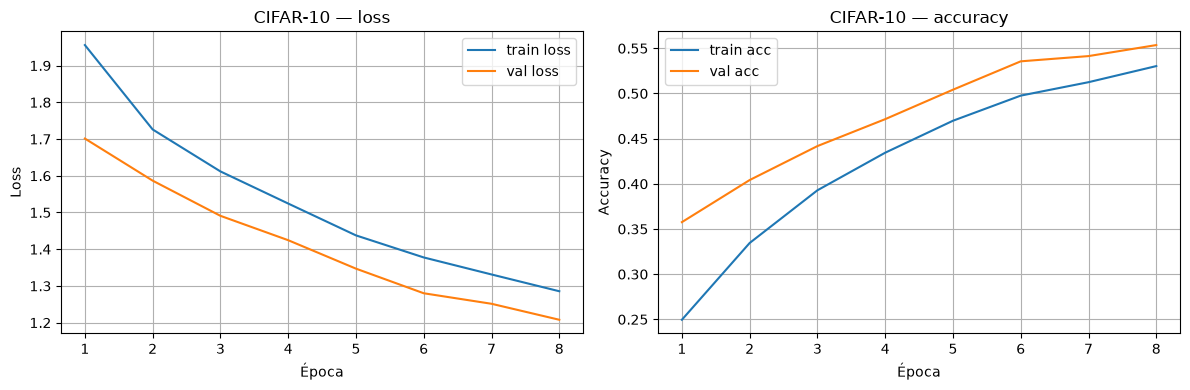

Test loss=1.2159 | accuracy=0.553
              precision    recall  f1-score   support

       avión      0.662     0.471     0.551      1000
        auto      0.753     0.593     0.663      1000
      pájaro      0.437     0.351     0.389      1000
        gato      0.423     0.246     0.311      1000
      ciervo      0.424     0.527     0.470      1000
       perro      0.497     0.447     0.471      1000
        rana      0.608     0.720     0.659      1000
     caballo      0.535     0.734     0.619      1000
       barco      0.581     0.792     0.670      1000
      camión      0.620     0.651     0.635      1000

    accuracy                          0.553     10000
   macro avg      0.554     0.553     0.544     10000
weighted avg      0.554     0.553     0.544     10000



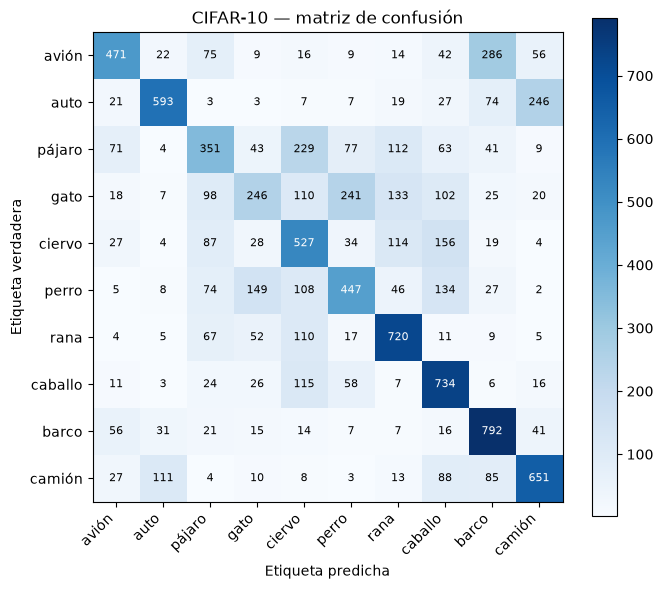

In [5]:
clf = Sequential([
    Conv2D(32, 3, activation="relu", padding="same", input_shape=(32, 32, 3)),
    MaxPooling2D(2),
    Conv2D(64, 3, activation="relu", padding="same"),
    MaxPooling2D(2),
    Conv2D(64, 3, activation="relu", padding="same"),
    GlobalAveragePooling2D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax"),
], name="cifar_cnn")
clf.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
clf.summary()

hist_clf = clf.fit(
    x_train, y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.1,
    callbacks=es_callbacks(3),
    verbose=1,
)
plot_history(hist_clf, "CIFAR-10")

loss, acc = clf.evaluate(x_test, y_test, verbose=0)
print(f"Test loss={loss:.4f} | accuracy={acc:.3f}")
y_pred = np.argmax(clf.predict(x_test, verbose=0), axis=1)
print(classification_report(y_test, y_pred, target_names=CIFAR_NAMES, digits=3))
plot_confusion_matrix(
    confusion_matrix(y_test, y_pred),
    CIFAR_NAMES,
    title="CIFAR-10 — matriz de confusión",
)


Una CNN pequeña en CIFAR-10 no rivaliza con un ResNet; el punto es el **contrato de la tarea**: una imagen → una clase. Los errores típicos (gato/perro, auto/camión) muestran clases visualmente cercanas, no un bug del `argmax`.


<a id="deteccion"></a>
<h2 style="color: #007ACC;">Detección de objetos</h2>


La detección responde **qué** y **dónde**. Para cada objeto se predice una clase y un **cuadro delimitador**. En coordenadas de imagen, $(x_{\min}, y_{\min})$ es la esquina **superior izquierda** ($y$ crece hacia abajo) y $(x_{\max}, y_{\max})$ la inferior derecha.

**Clasificación** (región o imagen):

$$\mathcal{L}_{\mathrm{cls}} = -\sum_{c=1}^{C} y_c \log \hat{y}_c$$

**Regresión de caja** (aquí $b=(x_{\min},y_{\min},x_{\max},y_{\max})$ normalizado a $[0,1]$):

$$\mathcal{L}_{\mathrm{reg}} = \lVert b - \hat{b} \rVert^2$$

**Pérdida conjunta:**

$$\mathcal{L} = \lambda_{\mathrm{cls}}\,\mathcal{L}_{\mathrm{cls}} + \lambda_{\mathrm{reg}}\,\mathcal{L}_{\mathrm{reg}}$$

<img src="../img/object-detection-models.jpg" alt="Backbone y dos cabezas" width="920">

La métrica habitual de localización es el **IoU** (*Intersection over Union*):

$$\mathrm{IoU}(A,B) = \frac{|A \cap B|}{|A \cup B|}$$

Un umbral típico de “acierto” es $\mathrm{IoU} \ge 0.5$.

**NMS** (*non-maximum suppression*, *supresión de no-máximos*): si varias cajas cubren el mismo objeto, se conserva la de mayor confianza y se descartan las que tienen IoU alto con ella. En este cuaderno hay **un objeto por imagen**, así que no hace falta NMS; sí hace falta en YOLO u otros detectores multi-objeto.


<a id="ejemplo-deteccion"></a>
<h2 style="color: #007ACC;">Ejemplo: un objeto sintético</h2>


Entrenar EfficientNet sobre **ruido gaussiano y cajas aleatorias** no enseña detección: no hay objeto que localizar. Aquí generamos lienzos $64	imes 64$ con **un círculo o un cuadrado** de color y posición aleatorios. La etiqueta es la clase y la caja que envuelve la figura. Un CNN pequeño con dos cabezas *puede* aprender esa geometría en pocos minutos.


Detección train: (2500, 64, 64, 3) (2500, 4) (2500,)


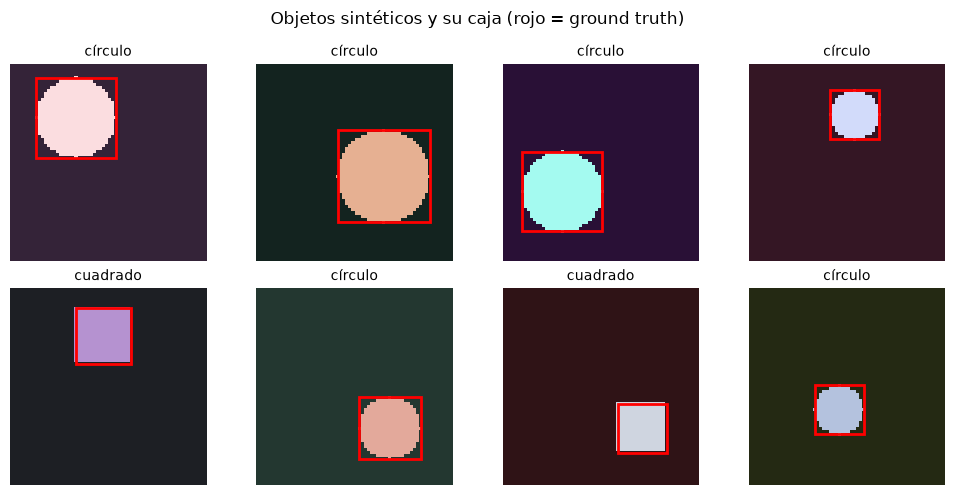

In [6]:
IMG = 64
DET_NAMES = ["círculo", "cuadrado"]


def _clip_box(xmin, ymin, xmax, ymax, size=IMG):
    xmin = int(np.clip(xmin, 0, size - 2))
    ymin = int(np.clip(ymin, 0, size - 2))
    xmax = int(np.clip(xmax, xmin + 1, size))
    ymax = int(np.clip(ymax, ymin + 1, size))
    return xmin, ymin, xmax, ymax


def make_shape(rng, with_mask=False):
    img = np.zeros((IMG, IMG, 3), dtype=np.float32)
    img[:] = rng.uniform(0.05, 0.25, size=3)
    cls = int(rng.integers(0, 2))
    rad = int(rng.integers(8, 16))
    cx = int(rng.integers(rad + 1, IMG - rad - 1))
    cy = int(rng.integers(rad + 1, IMG - rad - 1))
    color = rng.uniform(0.45, 1.0, size=3).astype(np.float32)
    yy, xx = np.ogrid[:IMG, :IMG]
    if cls == 0:
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= rad ** 2
        xmin, ymin, xmax, ymax = cx - rad, cy - rad, cx + rad, cy + rad
    else:
        xmin, ymin, xmax, ymax = cx - rad, cy - rad, cx + rad, cy + rad
        mask = np.zeros((IMG, IMG), dtype=bool)
        mask[ymin:ymax, xmin:xmax] = True
    img[mask] = color
    xmin, ymin, xmax, ymax = _clip_box(xmin, ymin, xmax, ymax)
    box = np.array([xmin, ymin, xmax, ymax], dtype=np.float32) / IMG
    if with_mask:
        return img, box, cls, mask.astype("float32")
    return img, box, cls


def make_detection_dataset(n, seed=SEED):
    rng = np.random.default_rng(seed)
    images = np.empty((n, IMG, IMG, 3), dtype=np.float32)
    boxes = np.empty((n, 4), dtype=np.float32)
    labels = np.empty((n,), dtype=np.int32)
    for i in range(n):
        images[i], boxes[i], labels[i] = make_shape(rng)
    return images, boxes, labels


def iou_np(a, b):
    """IoU por fila; cajas (xmin, ymin, xmax, ymax) en [0, 1]."""
    a = np.asarray(a, dtype=np.float32).reshape(-1, 4)
    b = np.asarray(b, dtype=np.float32).reshape(-1, 4)
    x1 = np.maximum(a[:, 0], b[:, 0])
    y1 = np.maximum(a[:, 1], b[:, 1])
    x2 = np.minimum(a[:, 2], b[:, 2])
    y2 = np.minimum(a[:, 3], b[:, 3])
    inter = np.maximum(0.0, x2 - x1) * np.maximum(0.0, y2 - y1)
    area_a = np.maximum(0.0, a[:, 2] - a[:, 0]) * np.maximum(0.0, a[:, 3] - a[:, 1])
    area_b = np.maximum(0.0, b[:, 2] - b[:, 0]) * np.maximum(0.0, b[:, 3] - b[:, 1])
    return inter / (area_a + area_b - inter + 1e-6)


def draw_box(ax, box, color, label=None):
    xmin, ymin, xmax, ymax = box
    rect = patches.Rectangle(
        (xmin * IMG, ymin * IMG),
        (xmax - xmin) * IMG,
        (ymax - ymin) * IMG,
        fill=False, edgecolor=color, linewidth=2, label=label,
    )
    ax.add_patch(rect)


x_det_tr, b_det_tr, y_det_tr = make_detection_dataset(2500, seed=SEED)
x_det_te, b_det_te, y_det_te = make_detection_dataset(400, seed=SEED + 1)
print("Detección train:", x_det_tr.shape, b_det_tr.shape, y_det_tr.shape)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, img, box, lab in zip(axes.ravel(), x_det_tr, b_det_tr, y_det_tr):
    ax.imshow(np.clip(img, 0, 1))
    draw_box(ax, box, "red")
    ax.set_title(DET_NAMES[lab], fontsize=10)
    ax.axis("off")
plt.suptitle("Objetos sintéticos y su caja (rojo = ground truth)")
plt.tight_layout()
plt.show()


Model: "detector_un_objeto"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ imagen (InputLayer) │ (None, 64, 64, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │        448 │ imagen[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │      4,640 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 8, 8, 64)  │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4096)      │          0 │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    524,416 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ box (Dense)         │ (None, 4)         │        516 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls (Dense)         │ (None, 2)         │        258 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 548,774 (2.09 MB)

 Trainable params: 548,774 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - box_loss: 0.0126 - box_mae: 0.0834 - cls_accuracy: 0.6047 - cls_loss: 0.6441 - loss: 0.6963 - val_box_loss: 0.0036 - val_box_mae: 0.0467 - val_cls_accuracy: 0.8373 - val_cls_loss: 0.4263 - val_loss: 0.4395 - learning_rate: 0.0010
Epoch 2/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - box_loss: 0.0069 - box_mae: 0.0657 - cls_accuracy: 0.9642 - cls_loss: 0.1161 - loss: 0.1446 - val_box_loss: 0.0021 - val_box_mae: 0.0363 - val_cls_accuracy: 1.0000 - val_cls_loss: 0.0102 - val_loss: 0.0187 - learning_rate: 0.0010
Epoch 3/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - box_loss: 0.0055 - box_mae: 0.0585 - cls_accuracy: 1.0000 - cls_loss: 0.0062 - loss: 0.0283 - val_box_loss: 0.0015 - val_box_mae: 0.0302 - val_cls_accuracy: 1.0000 - val_cls_loss: 0.0044 - val_loss: 0.0104 - learning_rate: 0.0010
Epoch 4/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - box_loss: 0.0041 - box_mae: 0.0498 - cls_accuracy: 1.0000 - cls_loss: 0.0032 - loss: 0.0194 - val_box_

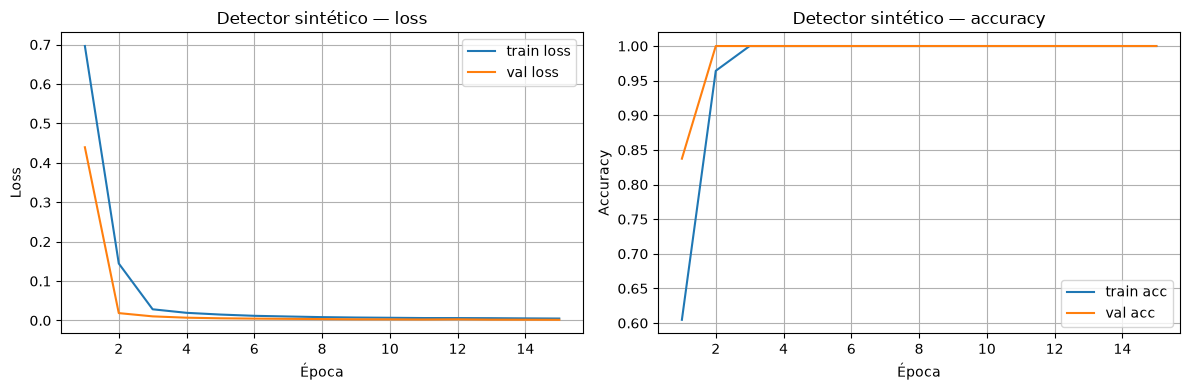

In [7]:
inp = Input(shape=(IMG, IMG, 3), name="imagen")
h = Conv2D(16, 3, activation="relu", padding="same")(inp)
h = MaxPooling2D(2)(h)
h = Conv2D(32, 3, activation="relu", padding="same")(h)
h = MaxPooling2D(2)(h)
h = Conv2D(64, 3, activation="relu", padding="same")(h)
h = MaxPooling2D(2)(h)
h = Flatten()(h)
h = Dense(128, activation="relu")(h)
h = Dropout(0.2)(h)
box_head = Dense(4, activation="sigmoid", name="box")(h)
cls_head = Dense(2, activation="softmax", name="cls")(h)

detector = Model(inp, [box_head, cls_head], name="detector_un_objeto")
detector.compile(
    optimizer="adam",
    loss={"box": "mse", "cls": "sparse_categorical_crossentropy"},
    loss_weights={"box": 4.0, "cls": 1.0},
    metrics={"box": "mae", "cls": "accuracy"},
)
detector.summary()

hist_det = detector.fit(
    x_det_tr,
    {"box": b_det_tr, "cls": y_det_tr},
    validation_split=0.15,
    epochs=15,
    batch_size=32,
    callbacks=es_callbacks(4),
    verbose=1,
)
plot_history(hist_det, "Detector sintético")


Accuracy de clase (test): 1.000
IoU medio (test):         0.838
Fracción con IoU ≥ 0.5:   1.000


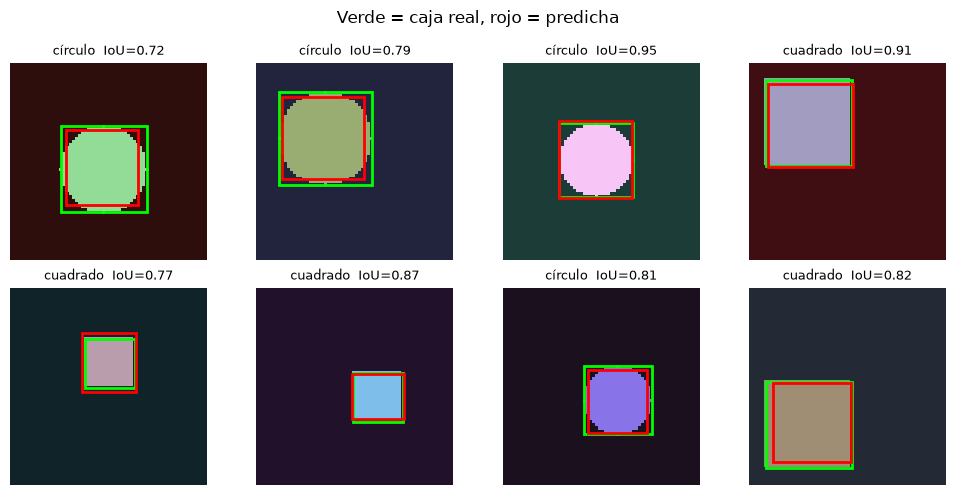

In [8]:
pred_box, pred_cls = detector.predict(x_det_te, verbose=0)
pred_lab = np.argmax(pred_cls, axis=1)
ious = iou_np(b_det_te, pred_box)
print(f"Accuracy de clase (test): {np.mean(pred_lab == y_det_te):.3f}")
print(f"IoU medio (test):         {ious.mean():.3f}")
print(f"Fracción con IoU ≥ 0.5:   {np.mean(ious >= 0.5):.3f}")

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, img, gt, pr, lab, hat, iou in zip(
    axes.ravel(), x_det_te, b_det_te, pred_box, y_det_te, pred_lab, ious
):
    ax.imshow(np.clip(img, 0, 1))
    draw_box(ax, gt, "lime", "GT")
    draw_box(ax, pr, "red", "pred")
    ax.set_title(f"{DET_NAMES[hat]}  IoU={iou:.2f}", fontsize=9)
    ax.axis("off")
plt.suptitle("Verde = caja real, rojo = predicha")
plt.tight_layout()
plt.show()


Si el IoU medio sube claramente por encima de un predictor trivial (una caja centrada a ojo), el modelo **sí** está localizando. Eso no ocurría con imágenes aleatorias: ahí $\mathcal{L}_{\mathrm{reg}}$ no tiene señal geométrica.


<a id="yolo"></a>
<h2 style="color: #007ACC;">YOLO (idea)</h2>


**YOLO** (*You Only Look Once*, Redmon et al., 2016) convierte la detección en **una sola pasada** de red: no hay etapa de propuestas tipo R-CNN.

1. La imagen se parte en una grilla $S \times S$.
2. La celda que contiene el **centro** del objeto predice su caja.
3. Cada celda predice $B$ cajas $(x,y,w,h)$, una **confianza** y $C$ clases.

En YOLOv1 el tensor de salida tiene forma $S \times S \times (B\cdot 5 + C)$. Después se aplica **NMS**.

<img src="../img/yolo.webp" alt="Grilla YOLO" width="640">

Las versiones posteriores (v3–v8, etc.) cambian cuello, anclas y pérdida; la idea didáctica sigue siendo: **un mapa espacial + cajas + clases en un solo forward**. Implementar YOLO completo se sale de este cuaderno; el detector de un objeto de arriba es el mismo contrato (clase + caja) en versión mínima.


<a id="segmentacion"></a>
<h2 style="color: #007ACC;">Segmentación semántica</h2>


Ahora cada píxel tiene clase. Si $I \in \mathbb{R}^{H \times W \times D}$, la máscara objetivo (one-hot) es $M \in \{0,1\}^{H \times W \times C}$ y la red produce $\hat{M}$ del **mismo** tamaño espacial, con softmax (multiclase) o sigmoid (binaria) por píxel.

$$\mathcal{L}_{\mathrm{CE}} = -\frac{1}{HW}\sum_{i,j,c} M_{ij}^{c}\,\log \hat{M}_{ij}^{c}$$

En máscaras desbalanceadas se usa a menudo el **Dice**:

$$\mathcal{L}_{\mathrm{Dice}} = 1 - \frac{2\sum M\hat{M}}{\sum M + \sum \hat{M} + \varepsilon}$$

**Segmentación de instancias** (Mask R-CNN, etc.) además separa *dos* gatos distintos; aquí solo semántica: todos los píxeles de “cuadrado” comparten clase.

Para recuperar $H\times W$ desde un mapa más chico se usa *upsampling* o **convolución transpuesta**, la misma pieza que en el autoencoder convolucional.


<a id="unet"></a>
<h2 style="color: #007ACC;">U-Net y ejemplo sintético</h2>


**U-Net** (Ronneberger et al., 2015) es un encoder–decoder en forma de U con **skip connections**: el decoder concatena mapas del encoder del mismo nivel. Así no se pierden bordes que el pooling había resumido.

<img src="../img/U-Net.avif" alt="Arquitectura U-Net" width="860">

Entrenamos una U-Net *mini* (dos niveles) para segmentar las mismas figuras sintéticas: entrada RGB, salida una máscara binaria $64\times 64\times 1$.


Seg train: (1800, 64, 64, 3) (1800, 64, 64, 1)


Model: "mini_unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │        448 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │      2,320 │ conv2d_6[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │      4,640 │ max_pooling2d_5[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │      9,248 │ conv2d_8[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 16, 16,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 16, 16,    │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 16, 16,    │     36,928 │ conv2d_10[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │      8,224 │ conv2d_11[0][0]   │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 32, 32,    │     18,464 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 32, 32,    │      9,248 │ conv2d_12[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 64, 64,    │      2,064 │ conv2d_13[0][0]   │
│ (Conv2DTranspose)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 32)               │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 64, 64,    │      4,624 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 64, 64,    │      2,320 │ conv2d_14[0][0] 

 Total params: 117,041 (457.19 KB)

 Trainable params: 117,041 (457.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.3323 - val_loss: 0.1045 - learning_rate: 0.0010
Epoch 2/12
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0429 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 3/12
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0051 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 4/12
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0028 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 5/12
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0019 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 6/12
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0014 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 7/12
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0012 - val_loss: 8.4743e-04 - learning_rate: 0.0010
Epoch 8/12
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0012 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 9/12
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0013 - val_loss: 6.4878e-04 - learning_rate: 0.0010
Epoch 10/12

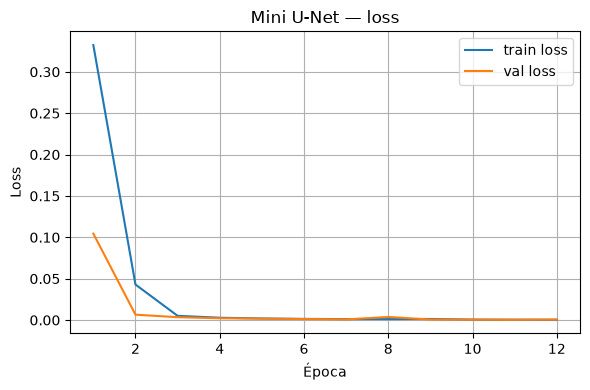

In [9]:
def make_seg_dataset(n, seed=SEED):
    rng = np.random.default_rng(seed)
    images = np.empty((n, IMG, IMG, 3), dtype=np.float32)
    masks = np.empty((n, IMG, IMG, 1), dtype=np.float32)
    for i in range(n):
        img, _, _, mask = make_shape(rng, with_mask=True)
        images[i] = img
        masks[i] = mask[..., np.newaxis]
    return images, masks


def conv_block(x, filters):
    x = Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x


def mini_unet(input_shape=(IMG, IMG, 3)):
    inp = Input(shape=input_shape)
    c1 = conv_block(inp, 16)
    p1 = MaxPooling2D(2)(c1)
    c2 = conv_block(p1, 32)
    p2 = MaxPooling2D(2)(c2)
    b = conv_block(p2, 64)
    u2 = Conv2DTranspose(32, 2, strides=2, padding="same")(b)
    u2 = Concatenate()([u2, c2])
    c3 = conv_block(u2, 32)
    u1 = Conv2DTranspose(16, 2, strides=2, padding="same")(c3)
    u1 = Concatenate()([u1, c1])
    c4 = conv_block(u1, 16)
    out = Conv2D(1, 1, activation="sigmoid")(c4)
    model = Model(inp, out, name="mini_unet")
    model.compile(optimizer="adam", loss="binary_crossentropy")
    return model


def dice_coef(y_true, y_pred, thresh=0.5, eps=1e-6):
    y_true = y_true.reshape(len(y_true), -1)
    y_pred = (y_pred.reshape(len(y_pred), -1) > thresh).astype(np.float32)
    inter = (y_true * y_pred).sum(axis=1)
    return float(np.mean((2 * inter + eps) / (y_true.sum(axis=1) + y_pred.sum(axis=1) + eps)))


x_seg_tr, m_seg_tr = make_seg_dataset(1800, seed=SEED)
x_seg_te, m_seg_te = make_seg_dataset(300, seed=SEED + 2)
print("Seg train:", x_seg_tr.shape, m_seg_tr.shape)

unet = mini_unet()
unet.summary()
hist_seg = unet.fit(
    x_seg_tr, m_seg_tr,
    validation_split=0.15,
    epochs=12,
    batch_size=32,
    callbacks=es_callbacks(3),
    verbose=1,
)
plot_history(hist_seg, "Mini U-Net")


Dice test: 1.000


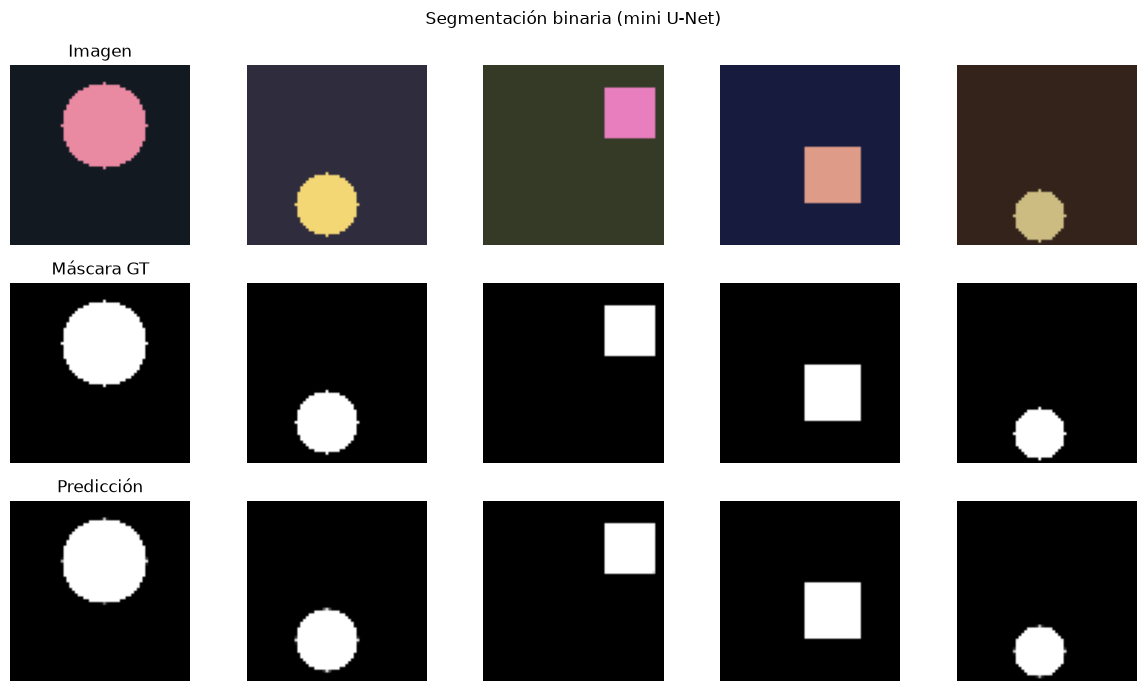

In [10]:
m_hat = unet.predict(x_seg_te, verbose=0)
print(f"Dice test: {dice_coef(m_seg_te, m_hat):.3f}")

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for j in range(5):
    axes[0, j].imshow(np.clip(x_seg_te[j], 0, 1))
    axes[0, j].set_title("Imagen" if j == 0 else "")
    axes[0, j].axis("off")
    axes[1, j].imshow(m_seg_te[j, :, :, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, j].set_title("Máscara GT" if j == 0 else "")
    axes[1, j].axis("off")
    axes[2, j].imshow(m_hat[j, :, :, 0], cmap="gray", vmin=0, vmax=1)
    axes[2, j].set_title("Predicción" if j == 0 else "")
    axes[2, j].axis("off")
plt.suptitle("Segmentación binaria (mini U-Net)")
plt.tight_layout()
plt.show()


Un Dice cercano a 1 en este juguete es esperable: hay un objeto nítido sobre fondo uniforme. En imágenes médicas o satelitales el mismo esqueleto de U-Net se entrena con más filtros, *augmentation* y a menudo $\mathcal{L}_{\mathrm{CE}}+\mathcal{L}_{\mathrm{Dice}}$.


<a id="problemas"></a>
<h2 style="color: #007ACC;">Problemas comunes</h2>


- **Confundir las tres tareas.** Una CNN de clasificación no “detecta”: no hay caja. Una máscara no es un `argmax` global.
- **Datos sintéticos sin estructura.** Cajas y etiquetas aleatorias sobre ruido no son un problema de detección.
- **Cajas inválidas.** Hay que imponer $x_{\max}>x_{\min}$ (y lo mismo en $y$). Coordenadas en píxeles vs $[0,1]$ mezcladas rompen el IoU.
- **Flatten en detección/segmentación.** Tira el mapa espacial; en detección conviene pooling global o un mapa; en segmentación, un decoder.
- **NMS mal traducido / omitido.** Con varios objetos, sin NMS el modelo devuelve decenas de cajas sobre el mismo objeto.
- **Clases desbalanceadas en segmentación.** El fondo domina la CE; el Dice (o *focal loss*) corrige el sesgo.
- **Resolución.** CIFAR $32\times 32$ no es ImageNet; U-Net de $64\times 64$ no es una radiografía clínica. El contrato de la tarea sí es el mismo.


<a id="reference"></a>
<h2 style="color: #007ACC;">Referencias</h2>


1. Géron, A. *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*. Cap. 14 (CNNs y visión).
2. Redmon, J. et al. (2016). You Only Look Once: Unified, Real-Time Object Detection. *CVPR*. [PDF](https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/Redmon_You_Only_Look_CVPR_2016_paper.pdf)
3. Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional Networks for Biomedical Image Segmentation. [arXiv:1505.04597](https://arxiv.org/abs/1505.04597)
4. Long, J., Shelhamer, E., & Darrell, T. (2015). Fully Convolutional Networks for Semantic Segmentation. *CVPR*.
5. Girshick, R. et al. (2014–2016). R-CNN / Fast R-CNN / Faster R-CNN.
6. TensorFlow. [Image classification](https://www.tensorflow.org/tutorials/images/classification) y [segmentation](https://www.tensorflow.org/tutorials/images/segmentation).
